In [1]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
# import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

In [2]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
def mod_grad(LON, LAT, field):
    ''' Compute the module of a gradient in F(x,y)
    ===========================================================================
    Input :
    -> LON: [m,n]
    -> LAT: [m,n]
    -> field: [m,n]
    ===========================================================================
    Output:
    -> |$\nabla( F[x,y] )$|
    ===========================================================================
    Felipe Vilela da Silva @ IMAS, UTas, AU
    27-11-2020
    '''
    
    [trash,dlonx]  = np.gradient(LON)
    dx = dlonx*np.cos(LAT*np.pi/180)*111195.
    [dlaty,trash] = np.gradient(LAT)
    dy = dlaty*111195.

    [dfy,dfx] = np.gradient(field)
    dfdx, dfdy = dfx/dx, dfy/dy
    
    _f_ = np.sqrt((dfdx)**2 + (dfdy)**2)
    
    return _f_

In [4]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [6]:
# import cosima_cookbook as cc
# # Importing the ocean depth on t-cells in the chosen time period and domain
# session = cc.database.create_session()
# expt01 = '01deg_jra55v140_iaf'  # 01-deg and daily experiment 
# bathy = cc.querying.getvar(expt01, 'ht', session, n=1)

## Import SST

In [7]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
time_sel = slice('2010-01-01', '2010-12-31')
SST  = xr.open_dataset(path+'sst_19820101-20211231_fromChrisC.nc').sst.load()[:,0]
SST = SST.sel().sel(time=time_sel)
lon_SST, lat_SST = SST.lon, SST.lat

In [8]:
LON_SST, LAT_SST = np.meshgrid(lon_SST, lat_SST)
SST_grad = np.zeros([SST.shape[0], SST.shape[1], SST.shape[2]])*np.nan
for t in range(len(SST)):
    SST_grad[t] = mod_grad(LON_SST, LAT_SST, SST[t])
    print(str(t/(len(SST)-1)*100) + '%', end = '\r')

100.0%27472527473%%%

In [9]:
SST_mean      = SST.mean('time').compute()
SST_grad_mean = np.nanmean(SST_grad, axis = 0)

/jobfs/169928358.gadi-pbs/ipykernel_319672/3650174869.py:2: RuntimeWarning: Mean of empty slice
  SST_grad_mean = np.nanmean(SST_grad, axis = 0)


## Near-surface atmospheric wind using the 1/4$^\circ$ ERA5

In [10]:
path_u = '/g/data/rt52/era5/single-levels/reanalysis/10u/'
path_v = '/g/data/rt52/era5/single-levels/reanalysis/10v/'
year = np.arange(2010,2011,1) # The daily data in 2000 is between the output folders from 108 and 119
files_u, files_v = np.array([]), np.array([])
## The files are in different directories
for i in range(len(year)):
    file_u, file_v = glob(path_u + str(year[i]) + '/*'), glob(path_v + str(year[i]) + '/*')
    file_u.sort()
    file_v.sort()
    files_u = np.append(files_u, file_u)
    files_v = np.append(files_v, file_v)

In [11]:
from functools import partial
def _preprocess(ds, lon_bnds, lat_bnds):
    return ds.sel(longitude = lon_bnds, latitude = lat_bnds)

yt_sel = slice(-30.5, -51)
xt_sel = slice(8, 76)
partial_func = partial(_preprocess, lon_bnds=xt_sel, lat_bnds=yt_sel)
data_u = xr.open_mfdataset(list(files_u), preprocess=partial_func)  
data_v = xr.open_mfdataset(list(files_v), preprocess=partial_func)  

In [12]:
# time_sel = slice('2008-01-01', '2008-12-31')
u_atm   = data_u.u10.sel(time=time_sel)
u_atm_daily = u_atm.resample(time='1D').mean('time').compute()
##############################################################
v_atm   = data_v.v10.sel(time=time_sel)
v_atm_daily = v_atm.resample(time='1D').mean('time').compute()
##############################################################
lon_atm, lat_atm = u_atm.longitude, u_atm.latitude

In [13]:
wind_speed = np.array([np.sqrt(u_atm_daily[t]**2 + v_atm_daily[t]**2) for t in tqdm(range(len(u_atm_daily)))])
wind_speed_mean = np.nanmean(wind_speed, axis = 0)

100%|██████████| 365/365 [00:03<00:00, 95.47it/s]


## Frontal position

In [14]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
# data_bathy      = glob(path + 'GMRTv3_7_20200805topo_standing_meander.grd')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
front_boundary = argnear(lon_front, 65)[0]
lon_front      = lon_front[:front_boundary]
lat_front      = lat_front[:,:front_boundary]
###################################################################
# lat_front_mean = np.nanmean(lat_front[12*13:12*14], axis = 0) ## for 2006
# lat_front_mean = np.nanmean(lat_front[12*15:12*16], axis = 0) ## for 2008
lat_front_mean = np.nanmean(lat_front[12*17:12*18], axis = 0) ## for 2010

/jobfs/169928358.gadi-pbs/ipykernel_319672/3242614526.py:15: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front[12*17:12*18], axis = 0) ## for 2010


## Figures

In [15]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)

extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')
ft, color_ = 8, 'w'

## Positions to extract the trends

In [19]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38

# 2010

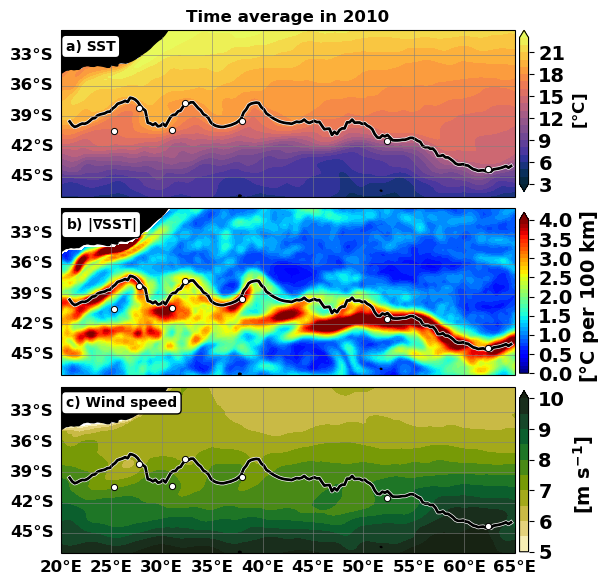

In [20]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:31,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[33:64,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[66:97,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon_SST, lat_SST, SST_mean, np.arange(3,24,1), cmap = cm.thermal, extend='both')
cf2 = ax[1].contourf(lon_SST, lat_SST, SST_grad_mean*1e5, np.arange(0,4.1,.1), cmap = 'jet', extend='max')
cf3 = ax[2].contourf(lon_atm, lat_atm, wind_speed_mean, np.arange(5,10.5,.5), cmap = cm.speed, extend='max')
# cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
# cf2 = ax[1].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')

# cr_SST = ax[1].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')

####################################### Details
for i in range(len(ax)):
    # ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 2:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

ax[0].annotate(text='a) SST', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text=r'b) |$\nabla$SST|', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[2].annotate(text='c) Wind speed', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
## Colorbar
bar = plt.axes([0.77, 0.65, 0.01, 0.23])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('[$\degree$C]', fontsize = 12) 

bar = plt.axes([0.77, 0.39, 0.01, 0.23])
cbar = plt.colorbar(cf2, cax = bar, format = '%.1f')  
cbar.set_label(r'[$\degree$C per 100 km]') 

bar = plt.axes([0.77, 0.135, 0.01, 0.23])
cbar = plt.colorbar(cf3, cax = bar, format = '%.0f')  
cbar.set_label(r'[m s$^{-1}$]') 

ax[0].set_title('Time average in 2010', fontsize = 12)

plt.savefig(path_fig + 'Fig_SST_grad_wind_2010.jpg', dpi =300, bbox_inches = 'tight')

# 2008

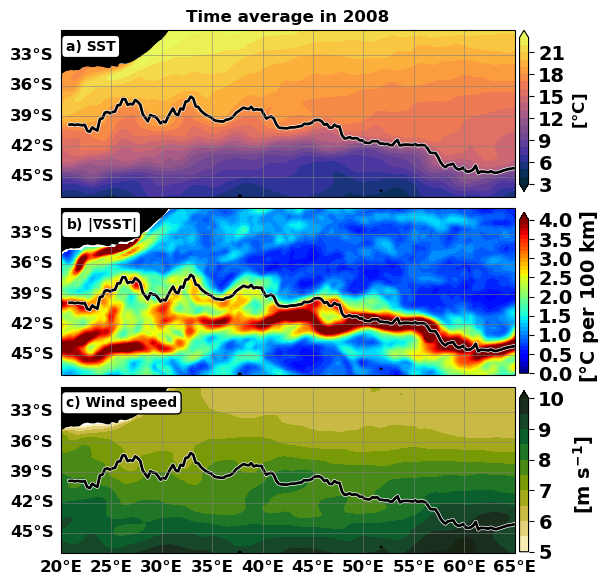

In [35]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:31,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[33:64,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[66:97,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon_SST, lat_SST, SST_mean, np.arange(3,24,1), cmap = cm.thermal, extend='both')
cf2 = ax[1].contourf(lon_SST, lat_SST, SST_grad_mean*1e5, np.arange(0,4.1,.1), cmap = 'jet', extend='max')
cf3 = ax[2].contourf(lon_atm, lat_atm, wind_speed_mean, np.arange(5,10.5,.5), cmap = cm.speed, extend='max')
# cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
# cf2 = ax[1].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')

# cr_SST = ax[1].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')

####################################### Details
for i in range(len(ax)):
    # ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 2:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].annotate(text='a) SST', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text=r'b) |$\nabla$SST|', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[2].annotate(text='c) Wind speed', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
## Colorbar
bar = plt.axes([0.77, 0.65, 0.01, 0.23])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('[$\degree$C]', fontsize = 12) 

bar = plt.axes([0.77, 0.39, 0.01, 0.23])
cbar = plt.colorbar(cf2, cax = bar, format = '%.1f')  
cbar.set_label(r'[$\degree$C per 100 km]') 

bar = plt.axes([0.77, 0.135, 0.01, 0.23])
cbar = plt.colorbar(cf3, cax = bar, format = '%.0f')  
cbar.set_label(r'[m s$^{-1}$]') 

ax[0].set_title('Time average in 2008', fontsize = 12)

plt.savefig(path_fig + 'Fig_SST_grad_wind_2008.jpg', dpi =300, bbox_inches = 'tight')

# 2006

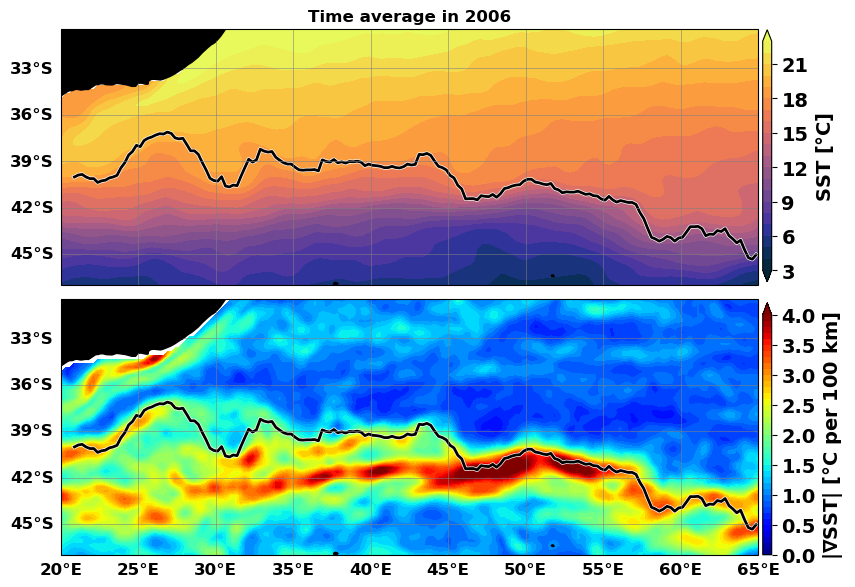

In [17]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:,:], projection=ccrs.PlateCarree()),]

cf1 = ax[0].contourf(lon_SST, lat_SST, SST_mean, np.arange(3,24,1), cmap = cm.thermal, extend='both')
cf2 = ax[1].contourf(lon_SST, lat_SST, SST_grad_mean*1e5, np.arange(0,4.1,.1), cmap = 'jet', extend='max')
# cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
# cf2 = ax[1].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')

# cr_SST = ax[1].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')

####################################### Details
for i in range(len(ax)):
    # ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 1:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

## Colorbar
bar = plt.axes([0.905, 0.51, 0.01, 0.36])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('SST [$\degree$C]') 

bar = plt.axes([0.905, 0.12, 0.01, 0.36])
cbar = plt.colorbar(cf2, cax = bar, format = '%.01f')  
cbar.set_label(r'$|\nabla$SST| [$\degree$C per 100 km]') 
ax[0].set_title('Time average in 2006', fontsize = 12)

plt.savefig(path_fig + 'Fig_SST_grad_2006.jpg', dpi =300, bbox_inches = 'tight')

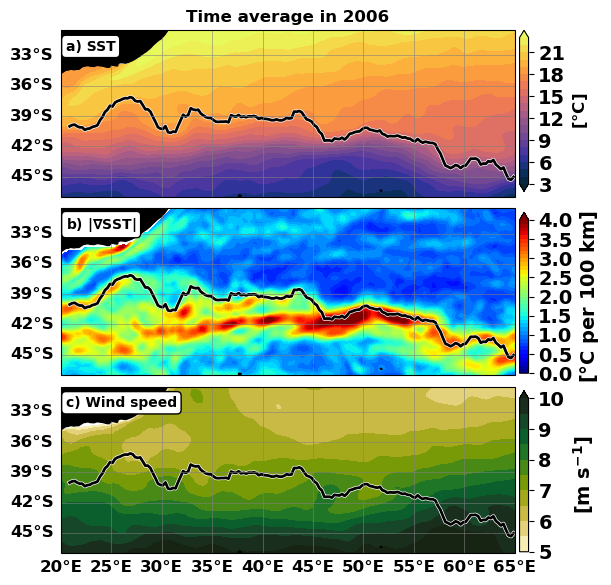

In [18]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:31,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[33:64,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[66:97,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon_SST, lat_SST, SST_mean, np.arange(3,24,1), cmap = cm.thermal, extend='both')
cf2 = ax[1].contourf(lon_SST, lat_SST, SST_grad_mean*1e5, np.arange(0,4.1,.1), cmap = 'jet', extend='max')
cf3 = ax[2].contourf(lon_atm, lat_atm, wind_speed_mean, np.arange(5,10.5,.5), cmap = cm.speed, extend='max')
# cf1 = ax[0].contourf(Ln, Lt, slope_decade_SLA*1e2, np.arange(-8, 8.1, .1), cmap = 'PuOr_r', extend='both')
# cf2 = ax[1].contourf(SST_lon, SST_lat, SST_trend, np.arange(-.4,.41,.01), cmap = cm.balance, extend='both')

# cr_SST = ax[1].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')

####################################### Details
for i in range(len(ax)):
    # ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 2:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].annotate(text='a) SST', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[1].annotate(text=r'b) |$\nabla$SST|', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
ax[2].annotate(text='c) Wind speed', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
## Colorbar
bar = plt.axes([0.77, 0.65, 0.01, 0.23])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('[$\degree$C]', fontsize = 12) 

bar = plt.axes([0.77, 0.39, 0.01, 0.23])
cbar = plt.colorbar(cf2, cax = bar, format = '%.1f')  
cbar.set_label(r'[$\degree$C per 100 km]') 

bar = plt.axes([0.77, 0.135, 0.01, 0.23])
cbar = plt.colorbar(cf3, cax = bar, format = '%.0f')  
cbar.set_label(r'[m s$^{-1}$]') 

ax[0].set_title('Time average in 2006', fontsize = 12)

plt.savefig(path_fig + 'Fig_SST_grad_wind_2006.jpg', dpi =300, bbox_inches = 'tight')